This notebook includes runs related to unmixing by using:

1. A very simple CNN, of various different channel sizes. These sizes for hidden channels, kernels, and modes are:
    - [8], [4, 4], [3, 3] 
    - [16, 16], [8, 8, 8], [3, 3, 3] 
    - [32, 32, 32], [16, 16, 16, 16], [3, 3, 3, 3] 
    - [64, 64, 64, 64], [32, 32, 32, 32, 32], [3, 3, 3, 3, 3] 
    - [128, 128, 128, 128, 128], [64, 64, 64, 64, 64, 64], [3, 3, 3, 3, 3, 3] 
    - [256, 256, 256, 256, 256, 256], [64, 64, 64, 64, 64, 64, 64], [3, 3, 3, 3, 3, 3, 3] 
2. P, Q, final projection networks as follows:
    - For P:
        - in_ch=1
        - out_ch=128
        - hidden_ch=[8, 32]
    - For Q:
        - in_ch=128
        - out_ch=32
        - hidden_ch=[32, 8]
    - For final projection:
        - Linear[32, 64]
        - GELU
        - Linear[64, 3]
3. Of varying learning rates fine tuned for the given model. With a Cosine annealing lr scheduler with warmup in first 10 epochs.
4. With dropout, optimized using AdamW.
5. A loss of simple MSE, with a small additional terms for sum of residuals.
6. With a training loop that loops over the entire training dataset at each epoch, with a max epochs of 80.
7. Data separated into 1500 training samples, 100 static validation samples, and 123 static test samples.
8. Trained using a GPU.
9. Statistically normalized datasets.
10. GELU as the activation function throughout.

### Imports, data, model initialization, and various other setups

In [10]:
# Set up autoreload
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
# Sys Imports
import sys
from pathlib import Path

github_root = Path.cwd().resolve().parents[3]
sys.path.append(str(github_root))

In [12]:
# Self-def imports

from src.dl.data import get_data
from src.dl.models.fno.FNO import FNO_nD
from src.dl.train import train_model

In [13]:
# Package imports
import torch
import torch.nn as nn

In [14]:
# Get device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [15]:
# Data hyperparams
save_path = rf"{github_root}\data\simpler_data_rwc.csv"

batch_size = 32
epoch = 80
n_tb_epoch = 47

In [16]:
# Define model configs

cfg_p = {
    'in_channels': 1, 
    'out_channels': 128, 
    'hidden_channels': [8, 32], 
    'dropout': 0.05,
    'act_fn': 'gelu'
}

cfg_q = {
    'in_channels': 128, 
    'out_channels': 32, 
    'hidden_channels': [128, 64], 
    'dropout': 0.05,
    'act_fn': 'gelu'
}



models_list = [
    {
        'fb_hidden_channels': [8], 'fb_modes': [[4], [4]], 'fb_kernel': [3, 3], 'cfg_p': cfg_p, 'cfg_q': cfg_q
    },
    {
        'fb_hidden_channels': [16,16], 'fb_modes': [[8], [8], [8]], 'fb_kernel': [3, 3, 3], 'cfg_p': cfg_p, 'cfg_q': cfg_q
    },
    {
        'fb_hidden_channels': [32,32,32], 'fb_modes': [[16], [16], [16], [16]], 'fb_kernel': [3, 3, 3, 3], 'cfg_p': cfg_p, 'cfg_q': cfg_q 
    },
    {
        'fb_hidden_channels': [64,64,64,64], 'fb_modes': [[32], [32], [32], [32], [32]], 'fb_kernel': [3, 3, 3, 3, 3], 'cfg_p': cfg_p, 'cfg_q': cfg_q 
    },
    {
        'fb_hidden_channels': [128,128,128,128,128], 'fb_modes': [[40], [40], [40], [40], [40], [40]], 'fb_kernel': [3, 3, 3, 3, 3, 3], 'cfg_p': cfg_p, 'cfg_q': cfg_q 
    },
    {
        'fb_hidden_channels': [256,256,256,256,256,256], 'fb_modes': [[40], [40], [40], [40], [40], [40], [40]], 'fb_kernel': [3, 3, 3, 3, 3, 3,3], 'cfg_p': cfg_p, 'cfg_q': cfg_q
    }
]

lr_list = [1e-3, 2.5e-3, 5e-3, 8e-4, 3e-4, 3e-4]

dir_list = [
    'fno_8',
    'fno_16',
    'fno_32',
    'fno_64',
    'fno_128',
    'fno_256'
]

name_list = [
        'FNO_8',
        'FNO_16',
        'FNO_32',
        'FNO_64',
        'FNO_128',
        'FNO_256'
    ]

# Create dirs

for dir_name in dir_list:
    save_dir = github_root / 'runs' / 'dl' / 'simpler_data' / 'fno' / dir_name
    save_dir.mkdir(parents=True, exist_ok=True)

### Model train loop

Epoch 1/80, Step 1/47, Train Loss: 0.110812
Epoch 1/80, Step 2/47, Train Loss: 0.111302
Epoch 1/80, Step 3/47, Train Loss: 0.088971
Epoch 1/80, Step 4/47, Train Loss: 0.085908
Epoch 1/80, Step 5/47, Train Loss: 0.095306
Epoch 1/80, Step 6/47, Train Loss: 0.096983
Epoch 1/80, Step 7/47, Train Loss: 0.100081
Epoch 1/80, Step 8/47, Train Loss: 0.108517
Epoch 1/80, Step 9/47, Train Loss: 0.115263
Epoch 1/80, Step 10/47, Train Loss: 0.093855
Epoch 1/80, Step 11/47, Train Loss: 0.082074
Epoch 1/80, Step 12/47, Train Loss: 0.097752
Epoch 1/80, Step 13/47, Train Loss: 0.099599
Epoch 1/80, Step 14/47, Train Loss: 0.091229
Epoch 1/80, Step 15/47, Train Loss: 0.092400
Epoch 1/80, Step 16/47, Train Loss: 0.085914
Epoch 1/80, Step 17/47, Train Loss: 0.102560
Epoch 1/80, Step 18/47, Train Loss: 0.100804
Epoch 1/80, Step 19/47, Train Loss: 0.126353
Epoch 1/80, Step 20/47, Train Loss: 0.099406
Epoch 1/80, Step 21/47, Train Loss: 0.096443
Epoch 1/80, Step 22/47, Train Loss: 0.104258
Epoch 1/80, Step 23

c:\Users\Ege\.code\Python\Python_311_Main\Lib\site-packages\torch\optim\lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 11/80, Step 16/47, Train Loss: 0.045134
Epoch 11/80, Step 17/47, Train Loss: 0.039662
Epoch 11/80, Step 18/47, Train Loss: 0.042744
Epoch 11/80, Step 19/47, Train Loss: 0.032772
Epoch 11/80, Step 20/47, Train Loss: 0.038061
Epoch 11/80, Step 21/47, Train Loss: 0.033380
Epoch 11/80, Step 22/47, Train Loss: 0.027074
Epoch 11/80, Step 23/47, Train Loss: 0.055104
Epoch 11/80, Step 24/47, Train Loss: 0.030629
Epoch 11/80, Step 25/47, Train Loss: 0.023350
Epoch 11/80, Step 26/47, Train Loss: 0.021050
Epoch 11/80, Step 27/47, Train Loss: 0.027284
Epoch 11/80, Step 28/47, Train Loss: 0.049151
Epoch 11/80, Step 29/47, Train Loss: 0.043231
Epoch 11/80, Step 30/47, Train Loss: 0.042457
Epoch 11/80, Step 31/47, Train Loss: 0.047091
Epoch 11/80, Step 32/47, Train Loss: 0.021976
Epoch 11/80, Step 33/47, Train Loss: 0.038231
Epoch 11/80, Step 34/47, Train Loss: 0.035116
Epoch 11/80, Step 35/47, Train Loss: 0.038418
Epoch 11/80, Step 36/47, Train Loss: 0.037548
Epoch 11/80, Step 37/47, Train Los

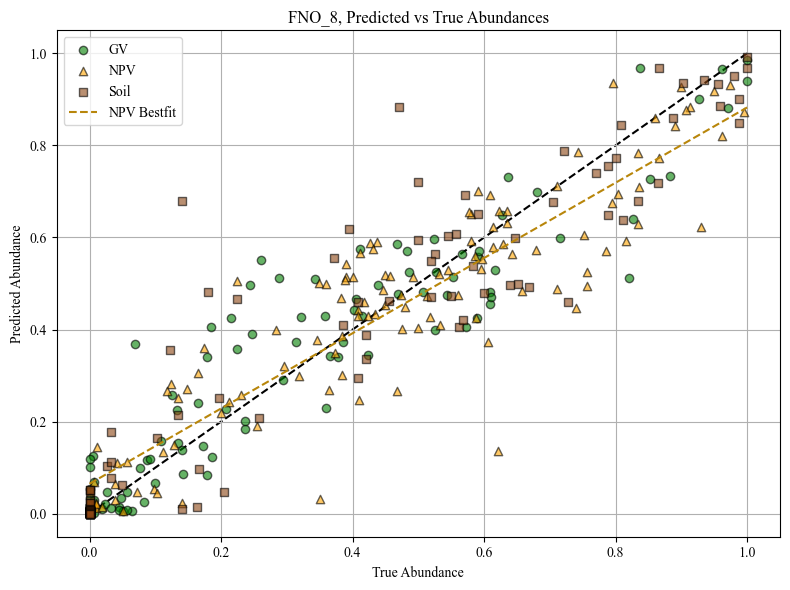

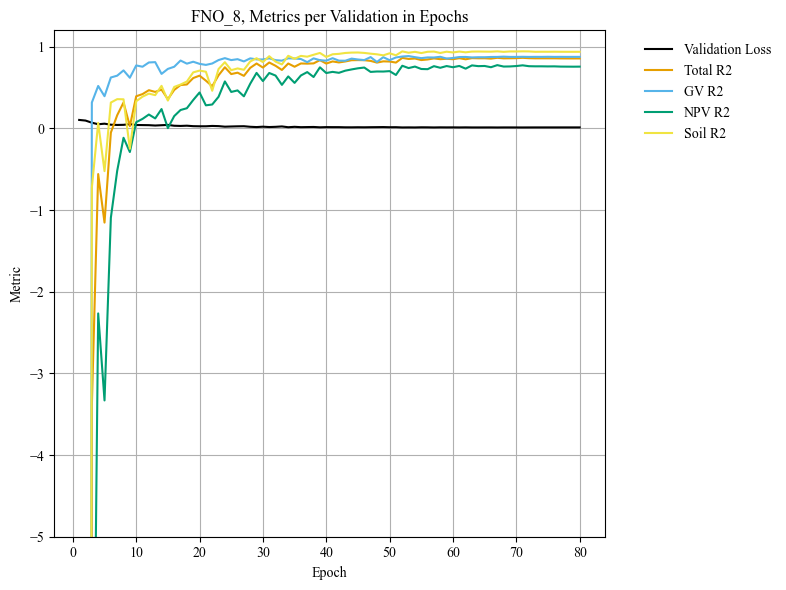

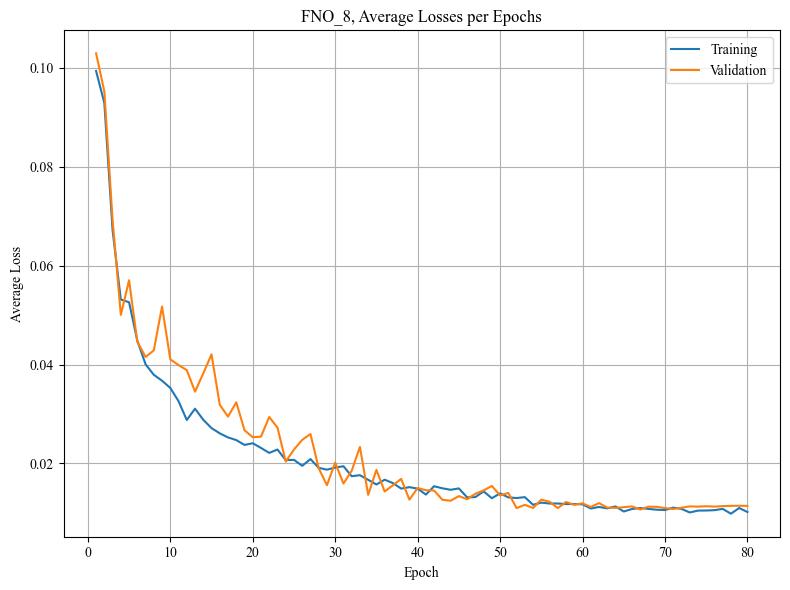

Testing complete
[[1.16539000e+05 1.70256800e+07 1.14051048e-02 8.53070080e-01
  8.82353723e-01 7.76576996e-01 9.00279522e-01 6.98808134e-02
  6.27908856e-02 8.67472440e-02 6.01043105e-02]]
Epoch 1/80, Step 1/47, Train Loss: 0.101635
Epoch 1/80, Step 2/47, Train Loss: 0.095592
Epoch 1/80, Step 3/47, Train Loss: 0.096149
Epoch 1/80, Step 4/47, Train Loss: 0.081700
Epoch 1/80, Step 5/47, Train Loss: 0.081561
Epoch 1/80, Step 6/47, Train Loss: 0.084485
Epoch 1/80, Step 7/47, Train Loss: 0.100717
Epoch 1/80, Step 8/47, Train Loss: 0.114011
Epoch 1/80, Step 9/47, Train Loss: 0.107977
Epoch 1/80, Step 10/47, Train Loss: 0.082181
Epoch 1/80, Step 11/47, Train Loss: 0.087977
Epoch 1/80, Step 12/47, Train Loss: 0.093704
Epoch 1/80, Step 13/47, Train Loss: 0.092003
Epoch 1/80, Step 14/47, Train Loss: 0.108822
Epoch 1/80, Step 15/47, Train Loss: 0.093545
Epoch 1/80, Step 16/47, Train Loss: 0.094319
Epoch 1/80, Step 17/47, Train Loss: 0.098117
Epoch 1/80, Step 18/47, Train Loss: 0.102940
Epoch 1/8

c:\Users\Ege\.code\Python\Python_311_Main\Lib\site-packages\torch\optim\lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 11/80, Step 4/47, Train Loss: 0.026272
Epoch 11/80, Step 5/47, Train Loss: 0.036889
Epoch 11/80, Step 6/47, Train Loss: 0.021669
Epoch 11/80, Step 7/47, Train Loss: 0.021341
Epoch 11/80, Step 8/47, Train Loss: 0.028499
Epoch 11/80, Step 9/47, Train Loss: 0.032832
Epoch 11/80, Step 10/47, Train Loss: 0.020968
Epoch 11/80, Step 11/47, Train Loss: 0.020446
Epoch 11/80, Step 12/47, Train Loss: 0.021449
Epoch 11/80, Step 13/47, Train Loss: 0.035388
Epoch 11/80, Step 14/47, Train Loss: 0.025437
Epoch 11/80, Step 15/47, Train Loss: 0.038998
Epoch 11/80, Step 16/47, Train Loss: 0.025923
Epoch 11/80, Step 17/47, Train Loss: 0.026844
Epoch 11/80, Step 18/47, Train Loss: 0.025220
Epoch 11/80, Step 19/47, Train Loss: 0.033635
Epoch 11/80, Step 20/47, Train Loss: 0.017250
Epoch 11/80, Step 21/47, Train Loss: 0.016388
Epoch 11/80, Step 22/47, Train Loss: 0.014318
Epoch 11/80, Step 23/47, Train Loss: 0.021761
Epoch 11/80, Step 24/47, Train Loss: 0.011575
Epoch 11/80, Step 25/47, Train Loss: 0.0

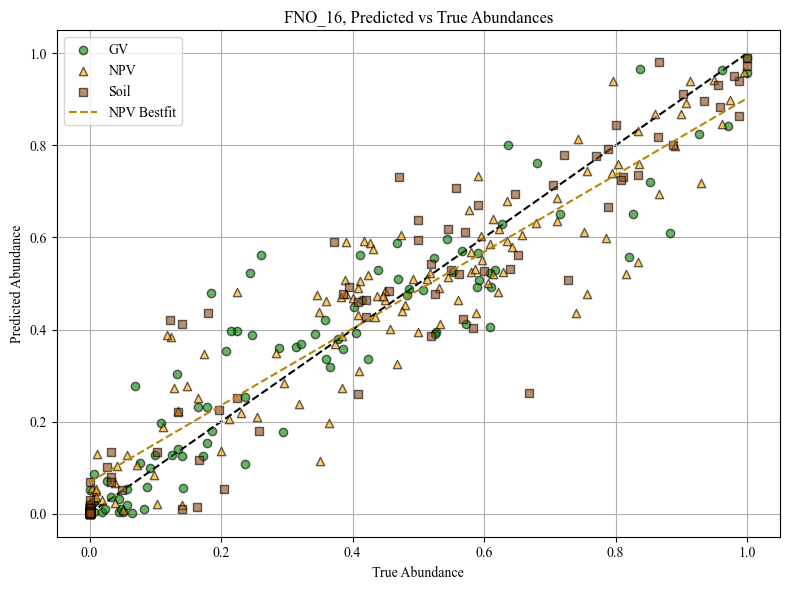

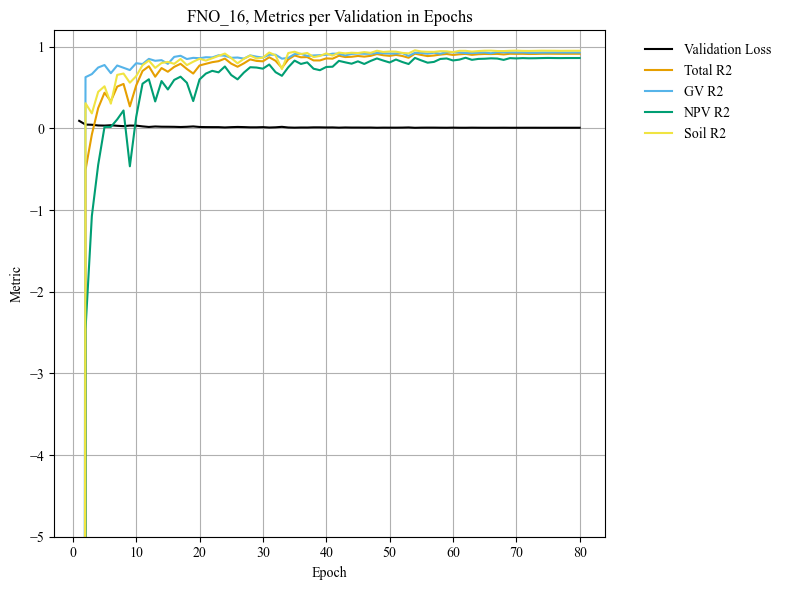

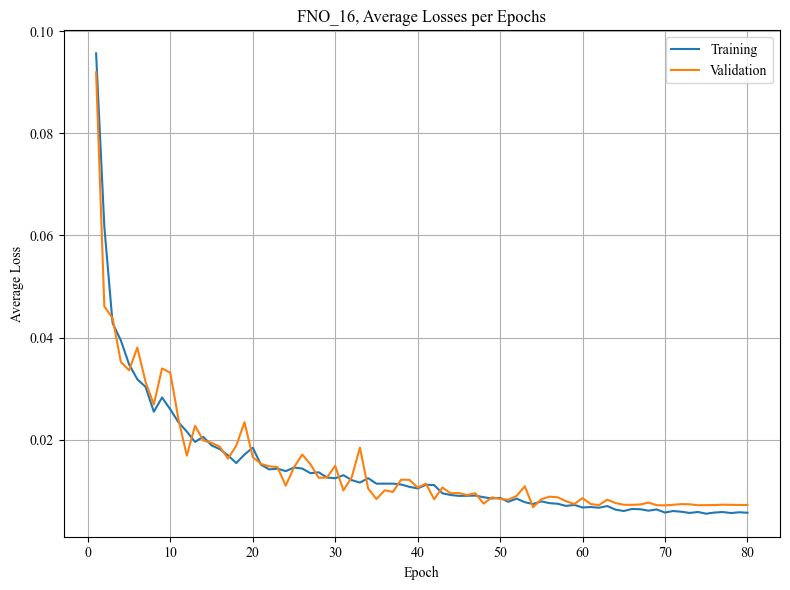

Testing complete
[[1.54019000e+05 1.88207520e+07 9.30581428e-03 8.78653347e-01
  8.87056470e-01 8.19785297e-01 9.29118335e-01 6.36811405e-02
  5.92510402e-02 8.06388482e-02 5.11535294e-02]]
Epoch 1/80, Step 1/47, Train Loss: 0.108902
Epoch 1/80, Step 2/47, Train Loss: 0.111971
Epoch 1/80, Step 3/47, Train Loss: 0.080818
Epoch 1/80, Step 4/47, Train Loss: 0.112000
Epoch 1/80, Step 5/47, Train Loss: 0.091131
Epoch 1/80, Step 6/47, Train Loss: 0.116284
Epoch 1/80, Step 7/47, Train Loss: 0.117872
Epoch 1/80, Step 8/47, Train Loss: 0.108288
Epoch 1/80, Step 9/47, Train Loss: 0.090550
Epoch 1/80, Step 10/47, Train Loss: 0.091753
Epoch 1/80, Step 11/47, Train Loss: 0.086866
Epoch 1/80, Step 12/47, Train Loss: 0.070214
Epoch 1/80, Step 13/47, Train Loss: 0.093592
Epoch 1/80, Step 14/47, Train Loss: 0.107950
Epoch 1/80, Step 15/47, Train Loss: 0.086817
Epoch 1/80, Step 16/47, Train Loss: 0.085400
Epoch 1/80, Step 17/47, Train Loss: 0.103074
Epoch 1/80, Step 18/47, Train Loss: 0.098729
Epoch 1/8

c:\Users\Ege\.code\Python\Python_311_Main\Lib\site-packages\torch\optim\lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 11/80, Step 4/47, Train Loss: 0.024548
Epoch 11/80, Step 5/47, Train Loss: 0.015155
Epoch 11/80, Step 6/47, Train Loss: 0.027703
Epoch 11/80, Step 7/47, Train Loss: 0.016799
Epoch 11/80, Step 8/47, Train Loss: 0.019330
Epoch 11/80, Step 9/47, Train Loss: 0.018795
Epoch 11/80, Step 10/47, Train Loss: 0.029825
Epoch 11/80, Step 11/47, Train Loss: 0.009436
Epoch 11/80, Step 12/47, Train Loss: 0.017079
Epoch 11/80, Step 13/47, Train Loss: 0.019310
Epoch 11/80, Step 14/47, Train Loss: 0.018946
Epoch 11/80, Step 15/47, Train Loss: 0.019807
Epoch 11/80, Step 16/47, Train Loss: 0.022855
Epoch 11/80, Step 17/47, Train Loss: 0.017177
Epoch 11/80, Step 18/47, Train Loss: 0.019509
Epoch 11/80, Step 19/47, Train Loss: 0.025610
Epoch 11/80, Step 20/47, Train Loss: 0.027740
Epoch 11/80, Step 21/47, Train Loss: 0.022512
Epoch 11/80, Step 22/47, Train Loss: 0.018932
Epoch 11/80, Step 23/47, Train Loss: 0.015419
Epoch 11/80, Step 24/47, Train Loss: 0.017146
Epoch 11/80, Step 25/47, Train Loss: 0.0

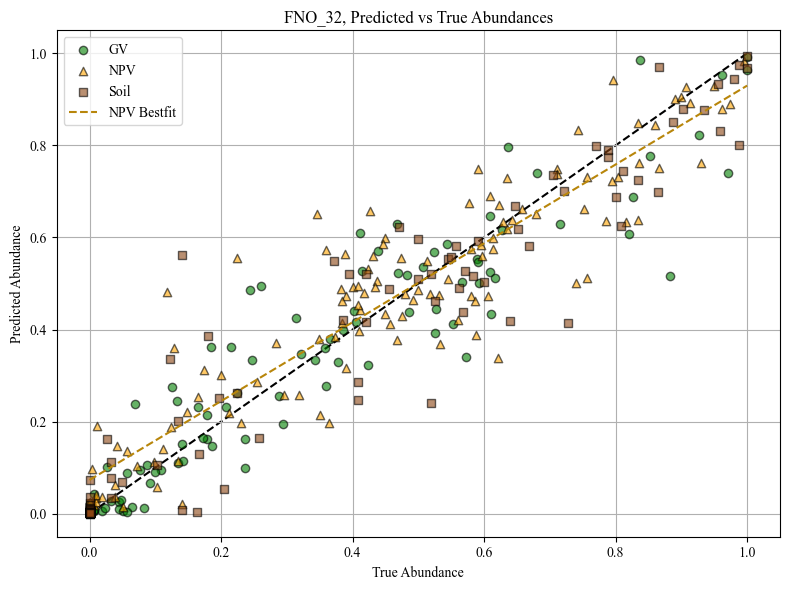

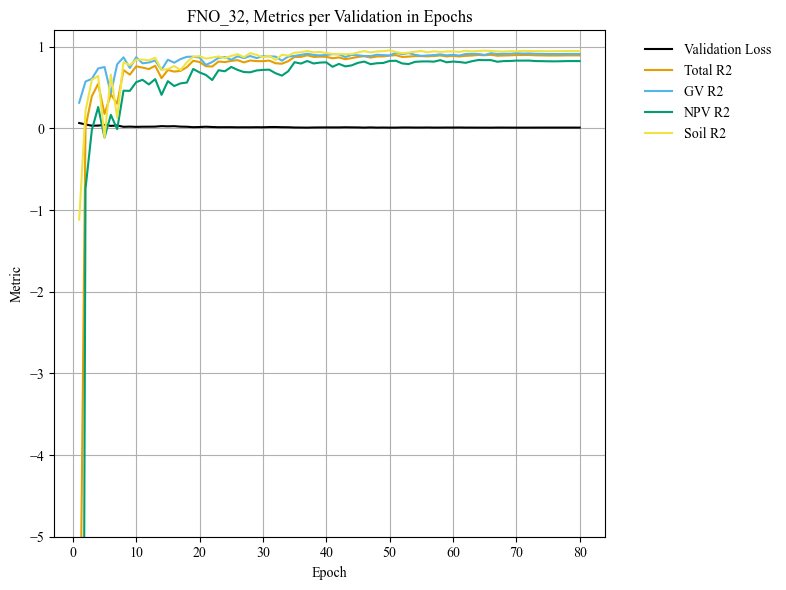

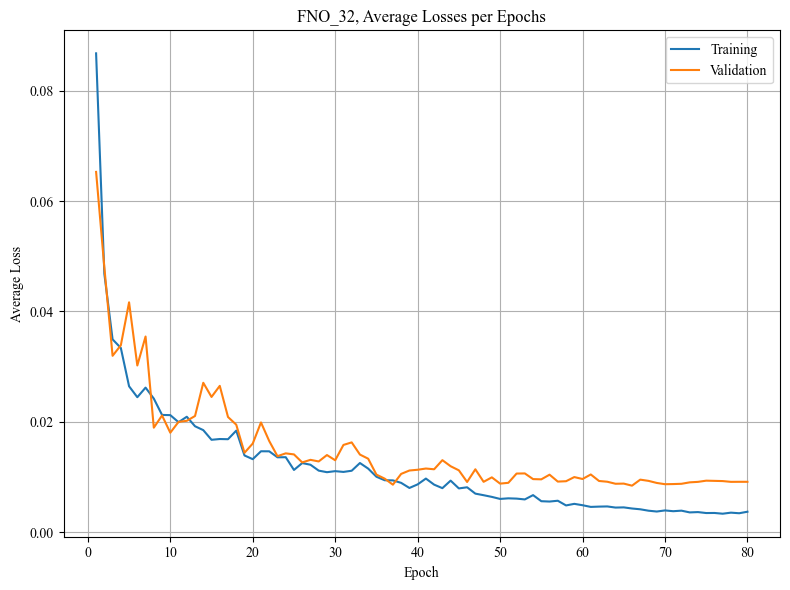

Testing complete
[[3.15315000e+05 2.42628000e+07 9.10788309e-03 8.82977188e-01
  8.96437466e-01 8.26794028e-01 9.25699949e-01 6.14194460e-02
  5.63999563e-02 7.87522048e-02 4.91061769e-02]]
Epoch 1/80, Step 1/47, Train Loss: 0.099567
Epoch 1/80, Step 2/47, Train Loss: 0.112545
Epoch 1/80, Step 3/47, Train Loss: 0.092809
Epoch 1/80, Step 4/47, Train Loss: 0.104154
Epoch 1/80, Step 5/47, Train Loss: 0.093677
Epoch 1/80, Step 6/47, Train Loss: 0.109686
Epoch 1/80, Step 7/47, Train Loss: 0.085520
Epoch 1/80, Step 8/47, Train Loss: 0.094644
Epoch 1/80, Step 9/47, Train Loss: 0.090050
Epoch 1/80, Step 10/47, Train Loss: 0.102177
Epoch 1/80, Step 11/47, Train Loss: 0.096237
Epoch 1/80, Step 12/47, Train Loss: 0.110039
Epoch 1/80, Step 13/47, Train Loss: 0.102746
Epoch 1/80, Step 14/47, Train Loss: 0.095944
Epoch 1/80, Step 15/47, Train Loss: 0.093853
Epoch 1/80, Step 16/47, Train Loss: 0.094040
Epoch 1/80, Step 17/47, Train Loss: 0.109173
Epoch 1/80, Step 18/47, Train Loss: 0.090032
Epoch 1/8

c:\Users\Ege\.code\Python\Python_311_Main\Lib\site-packages\torch\optim\lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 11/80, Step 6/47, Train Loss: 0.034573
Epoch 11/80, Step 7/47, Train Loss: 0.012062
Epoch 11/80, Step 8/47, Train Loss: 0.021518
Epoch 11/80, Step 9/47, Train Loss: 0.028602
Epoch 11/80, Step 10/47, Train Loss: 0.024689
Epoch 11/80, Step 11/47, Train Loss: 0.014513
Epoch 11/80, Step 12/47, Train Loss: 0.018323
Epoch 11/80, Step 13/47, Train Loss: 0.011124
Epoch 11/80, Step 14/47, Train Loss: 0.015996
Epoch 11/80, Step 15/47, Train Loss: 0.018161
Epoch 11/80, Step 16/47, Train Loss: 0.019249
Epoch 11/80, Step 17/47, Train Loss: 0.026633
Epoch 11/80, Step 18/47, Train Loss: 0.011317
Epoch 11/80, Step 19/47, Train Loss: 0.029473
Epoch 11/80, Step 20/47, Train Loss: 0.020774
Epoch 11/80, Step 21/47, Train Loss: 0.027986
Epoch 11/80, Step 22/47, Train Loss: 0.023408
Epoch 11/80, Step 23/47, Train Loss: 0.022503
Epoch 11/80, Step 24/47, Train Loss: 0.020284
Epoch 11/80, Step 25/47, Train Loss: 0.026280
Epoch 11/80, Step 26/47, Train Loss: 0.015161
Epoch 11/80, Step 27/47, Train Loss: 0

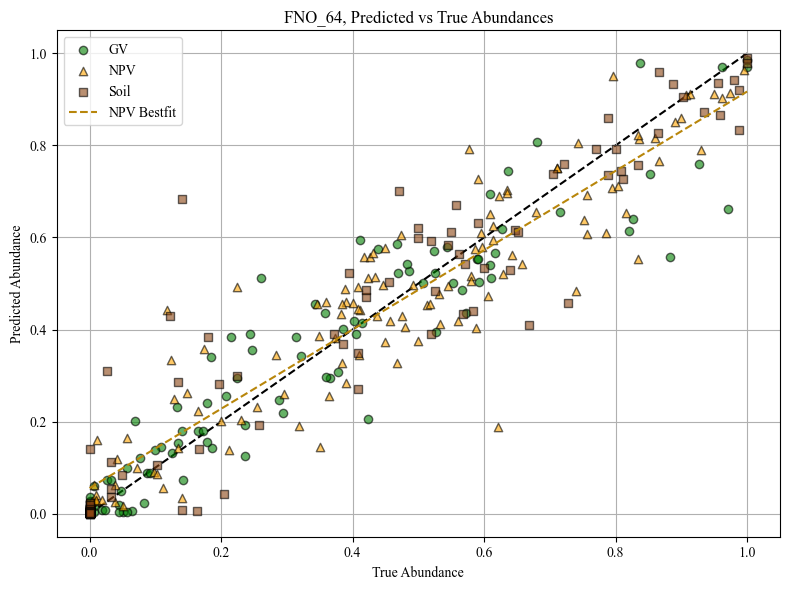

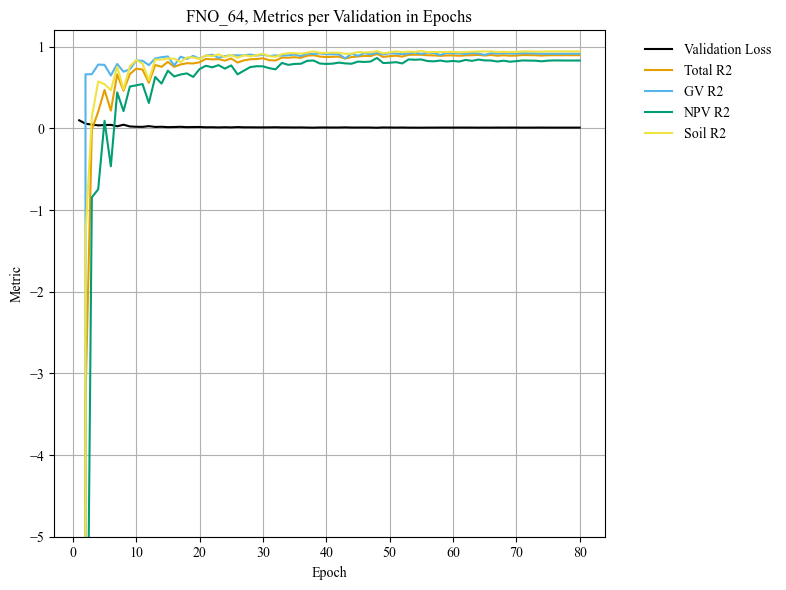

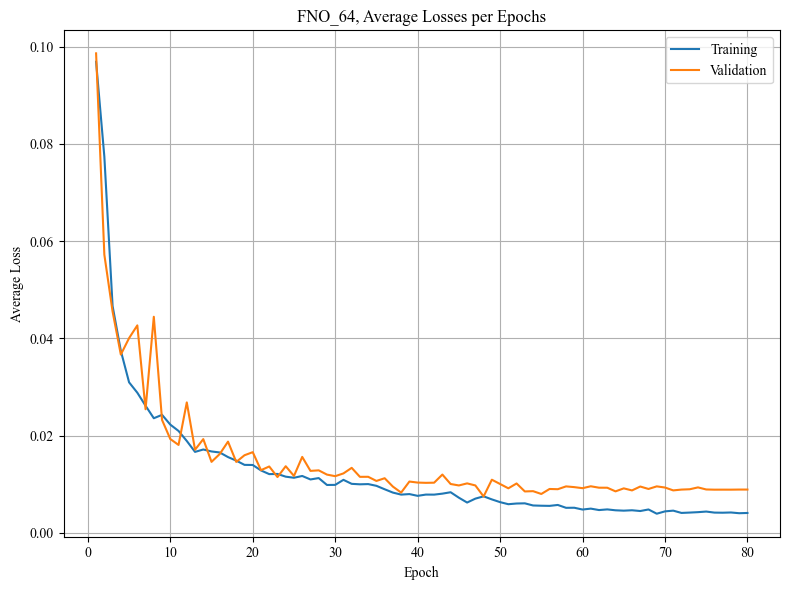

Testing complete
[[1.18638700e+06 4.46813600e+07 9.14376788e-03 8.85967672e-01
  9.04101849e-01 8.33922923e-01 9.19878185e-01 6.20530955e-02
  5.50223961e-02 7.96434134e-02 5.14934659e-02]]
Epoch 1/80, Step 1/47, Train Loss: 0.101420
Epoch 1/80, Step 2/47, Train Loss: 0.115211
Epoch 1/80, Step 3/47, Train Loss: 0.093952
Epoch 1/80, Step 4/47, Train Loss: 0.102308
Epoch 1/80, Step 5/47, Train Loss: 0.103988
Epoch 1/80, Step 6/47, Train Loss: 0.088581
Epoch 1/80, Step 7/47, Train Loss: 0.109459
Epoch 1/80, Step 8/47, Train Loss: 0.099426
Epoch 1/80, Step 9/47, Train Loss: 0.106076
Epoch 1/80, Step 10/47, Train Loss: 0.101455
Epoch 1/80, Step 11/47, Train Loss: 0.111664
Epoch 1/80, Step 12/47, Train Loss: 0.100497
Epoch 1/80, Step 13/47, Train Loss: 0.119196
Epoch 1/80, Step 14/47, Train Loss: 0.099936
Epoch 1/80, Step 15/47, Train Loss: 0.091144
Epoch 1/80, Step 16/47, Train Loss: 0.104649
Epoch 1/80, Step 17/47, Train Loss: 0.114476
Epoch 1/80, Step 18/47, Train Loss: 0.105856
Epoch 1/8

c:\Users\Ege\.code\Python\Python_311_Main\Lib\site-packages\torch\optim\lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 11/80, Step 4/47, Train Loss: 0.020056
Epoch 11/80, Step 5/47, Train Loss: 0.015236
Epoch 11/80, Step 6/47, Train Loss: 0.007207
Epoch 11/80, Step 7/47, Train Loss: 0.012860
Epoch 11/80, Step 8/47, Train Loss: 0.009028
Epoch 11/80, Step 9/47, Train Loss: 0.016878
Epoch 11/80, Step 10/47, Train Loss: 0.028792
Epoch 11/80, Step 11/47, Train Loss: 0.019400
Epoch 11/80, Step 12/47, Train Loss: 0.019655
Epoch 11/80, Step 13/47, Train Loss: 0.021246
Epoch 11/80, Step 14/47, Train Loss: 0.025530
Epoch 11/80, Step 15/47, Train Loss: 0.015534
Epoch 11/80, Step 16/47, Train Loss: 0.019089
Epoch 11/80, Step 17/47, Train Loss: 0.007923
Epoch 11/80, Step 18/47, Train Loss: 0.016243
Epoch 11/80, Step 19/47, Train Loss: 0.021521
Epoch 11/80, Step 20/47, Train Loss: 0.012188
Epoch 11/80, Step 21/47, Train Loss: 0.015411
Epoch 11/80, Step 22/47, Train Loss: 0.018166
Epoch 11/80, Step 23/47, Train Loss: 0.015079
Epoch 11/80, Step 24/47, Train Loss: 0.015147
Epoch 11/80, Step 25/47, Train Loss: 0.0

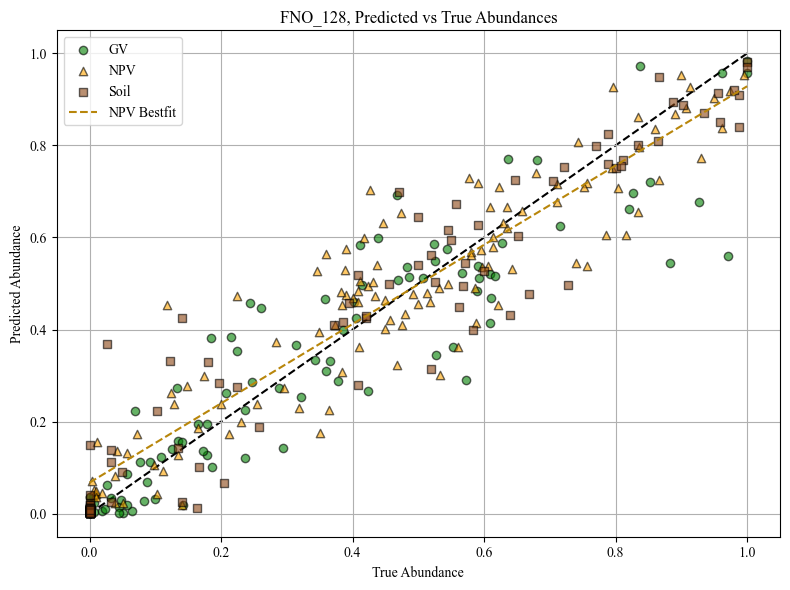

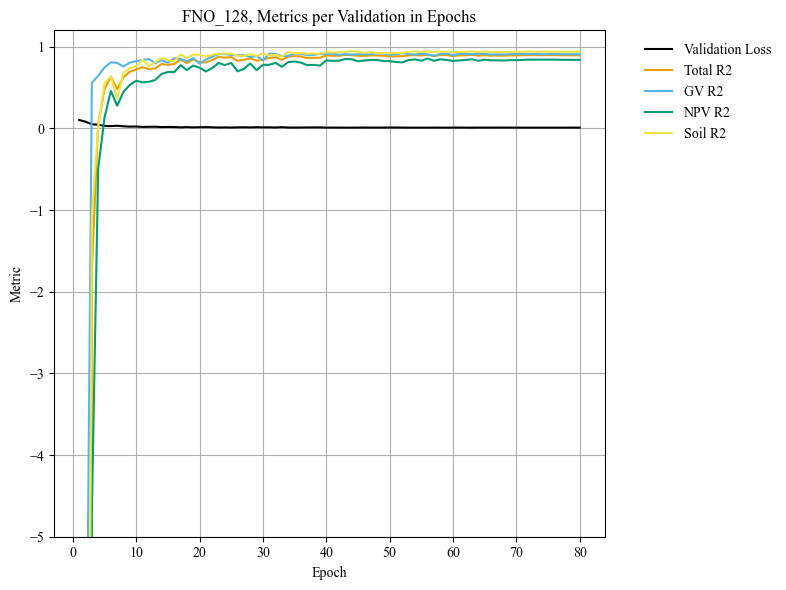

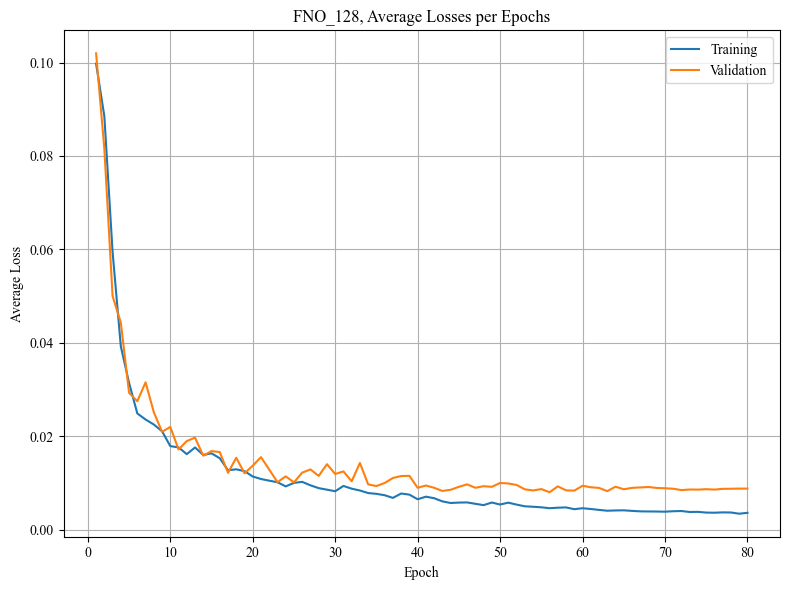

Testing complete
[[4.65704300e+06 1.24364944e+08 9.22004227e-03 8.79387140e-01
  8.63441885e-01 8.38709116e-01 9.36010301e-01 6.48451596e-02
  6.36840761e-02 8.05233791e-02 5.03280312e-02]]
Epoch 1/80, Step 1/47, Train Loss: 0.101011
Epoch 1/80, Step 2/47, Train Loss: 0.094278
Epoch 1/80, Step 3/47, Train Loss: 0.104244
Epoch 1/80, Step 4/47, Train Loss: 0.098755
Epoch 1/80, Step 5/47, Train Loss: 0.099794
Epoch 1/80, Step 6/47, Train Loss: 0.098443
Epoch 1/80, Step 7/47, Train Loss: 0.107851
Epoch 1/80, Step 8/47, Train Loss: 0.104355
Epoch 1/80, Step 9/47, Train Loss: 0.098436
Epoch 1/80, Step 10/47, Train Loss: 0.108193
Epoch 1/80, Step 11/47, Train Loss: 0.083503
Epoch 1/80, Step 12/47, Train Loss: 0.104673
Epoch 1/80, Step 13/47, Train Loss: 0.102854
Epoch 1/80, Step 14/47, Train Loss: 0.084621
Epoch 1/80, Step 15/47, Train Loss: 0.114725
Epoch 1/80, Step 16/47, Train Loss: 0.104024
Epoch 1/80, Step 17/47, Train Loss: 0.093387
Epoch 1/80, Step 18/47, Train Loss: 0.113600
Epoch 1/8

c:\Users\Ege\.code\Python\Python_311_Main\Lib\site-packages\torch\optim\lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 10/80 complete. Train Loss: 0.018030, Val Loss: 0.022609
Epoch 11/80, Step 1/47, Train Loss: 0.017646
Epoch 11/80, Step 2/47, Train Loss: 0.017973
Epoch 11/80, Step 3/47, Train Loss: 0.018052
Epoch 11/80, Step 4/47, Train Loss: 0.015743
Epoch 11/80, Step 5/47, Train Loss: 0.016622
Epoch 11/80, Step 6/47, Train Loss: 0.020006
Epoch 11/80, Step 7/47, Train Loss: 0.019279
Epoch 11/80, Step 8/47, Train Loss: 0.028711
Epoch 11/80, Step 9/47, Train Loss: 0.019965
Epoch 11/80, Step 10/47, Train Loss: 0.023593
Epoch 11/80, Step 11/47, Train Loss: 0.017540
Epoch 11/80, Step 12/47, Train Loss: 0.012290
Epoch 11/80, Step 13/47, Train Loss: 0.014195
Epoch 11/80, Step 14/47, Train Loss: 0.022917
Epoch 11/80, Step 15/47, Train Loss: 0.010522
Epoch 11/80, Step 16/47, Train Loss: 0.011280
Epoch 11/80, Step 17/47, Train Loss: 0.014527
Epoch 11/80, Step 18/47, Train Loss: 0.012623
Epoch 11/80, Step 19/47, Train Loss: 0.008580
Epoch 11/80, Step 20/47, Train Loss: 0.014783
Epoch 11/80, Step 21/47, T

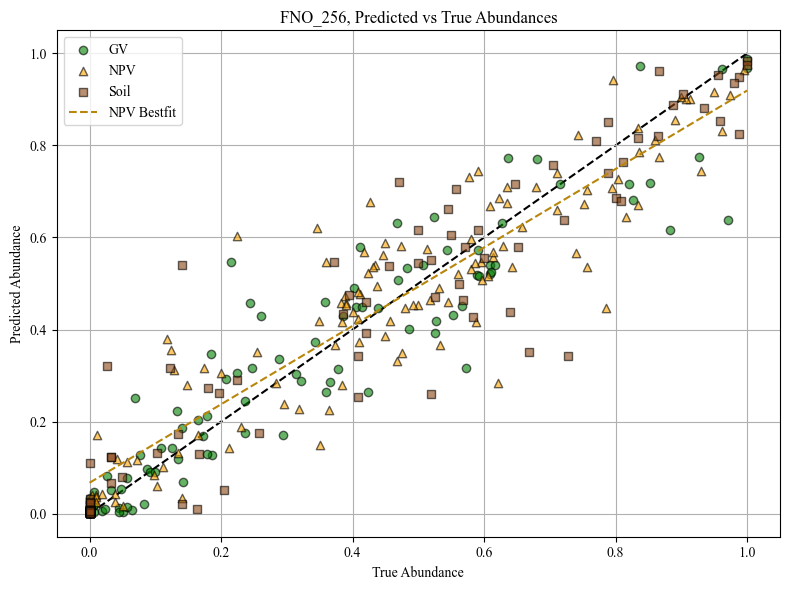

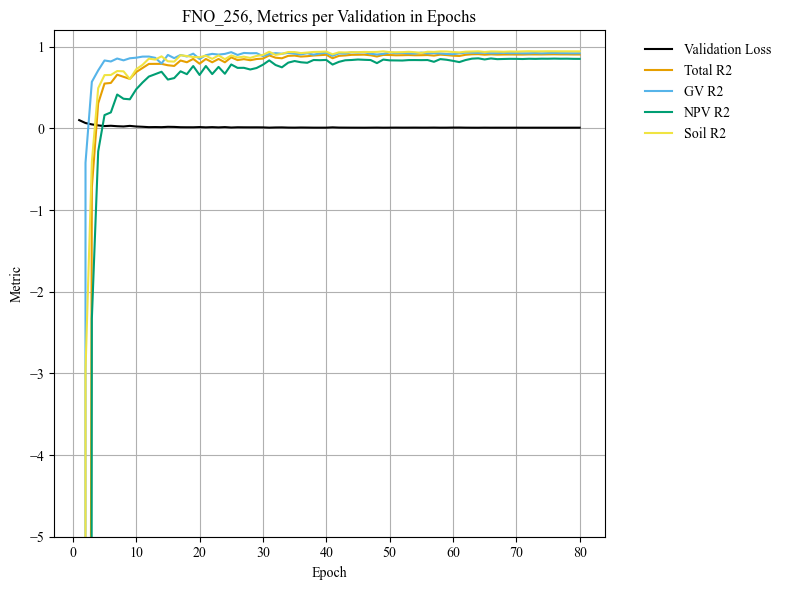

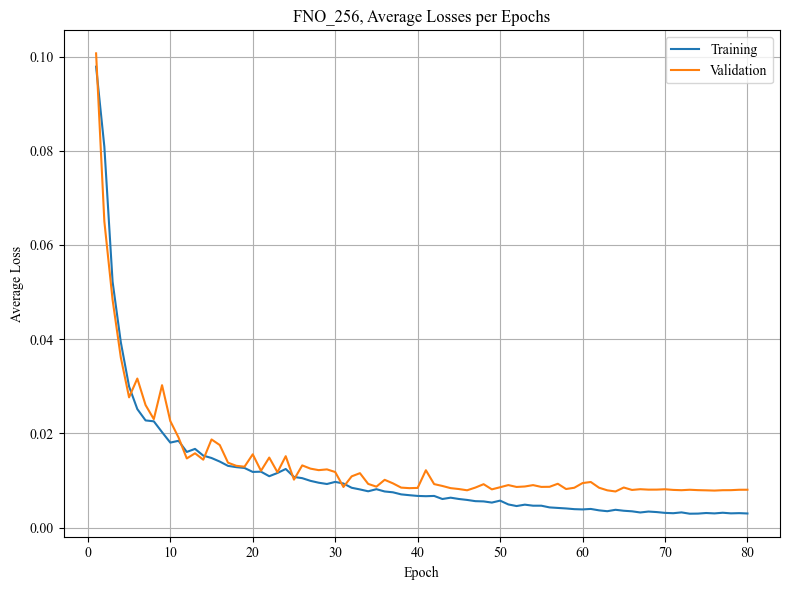

Testing complete
[[1.86529470e+07 5.03621776e+08 9.76348948e-03 8.76352608e-01
  8.94914627e-01 8.17816019e-01 9.16327238e-01 6.54035732e-02
  5.74243888e-02 8.34252313e-02 5.53610958e-02]]


In [17]:
fno_dict = {}
import gc


for i in range(len(models_list)):
    
    cfg_dict = models_list[i]
    lr = lr_list[i]
    save_dir = dir_list[i]
    model_name = name_list[i]

    dataloaders = get_data(save_path=save_path, spec_range=[900, 1700], batch_size=32)
    model = FNO_nD(**cfg_dict).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)

    warmup_epochs = 10 
    total_steps = epoch * n_tb_epoch
    warmup_steps = warmup_epochs * n_tb_epoch
    # warmup
    warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
        optimizer, 
        start_factor=0.1, 
        total_iters=warmup_steps
    )
    # cosine annealing
    main_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, 
        T_max=total_steps - warmup_steps, 
        eta_min=1e-6
    )
    # combination
    lr_scheduler = torch.optim.lr_scheduler.SequentialLR(
        optimizer,
        schedulers=[warmup_scheduler, main_scheduler],
        milestones=[warmup_steps]
    )

    loss = nn.MSELoss()

    model_dict = train_model(
        model=model,
        loss_fn=loss,
        optimizer=optimizer,
        lr_scheduler=lr_scheduler,
        configured_data=dataloaders,
        n_epoch=epoch,
        n_tb_epoch=n_tb_epoch,
        device=device,
        dtype=torch.float32,
        save_dir=save_dir,
        model_name=model_name
    )

    # After training a model and saving it to the dict/disk
    del model 
    gc.collect()
    torch.cuda.empty_cache()

    fno_dict[model_name] = model_dict
    print(fno_dict[model_name]['metrics_total'])

In [18]:
import pickle
with open('fno_dict.pkl', 'wb') as fp:
    pickle.dump(fno_dict, fp)

In [28]:
# Best models
best_models = [64,128,256]

for i in best_models:
    key = f'FNO_{i}'
    print(f'{key}, {fno_dict[key]["metrics_total"]}')


FNO_64, [[1.18638700e+06 4.46813600e+07 9.14376788e-03 8.85967672e-01
  9.04101849e-01 8.33922923e-01 9.19878185e-01 6.20530955e-02
  5.50223961e-02 7.96434134e-02 5.14934659e-02]]
FNO_128, [[4.65704300e+06 1.24364944e+08 9.22004227e-03 8.79387140e-01
  8.63441885e-01 8.38709116e-01 9.36010301e-01 6.48451596e-02
  6.36840761e-02 8.05233791e-02 5.03280312e-02]]
FNO_256, [[1.86529470e+07 5.03621776e+08 9.76348948e-03 8.76352608e-01
  8.94914627e-01 8.17816019e-01 9.16327238e-01 6.54035732e-02
  5.74243888e-02 8.34252313e-02 5.53610958e-02]]
